---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
        fontsize: 18px
        code-fold: true
        code-summary: "Show the code"
        code-tools: true
        code-copy: false
        number-sections: true

title: Market Regimes Study - Bitcoin
author: Rui Carvalho Caseiro
date: last-modified

warning: False
toc: True
---

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from MyCustomLibrary.main import timer

## Data

In [2]:
from MyCustomLibrary.data import BTC_Daily

quotes = BTC_Daily.droplevel(level=0, axis='columns')
quotes.drop(columns='Adj Close', inplace=True)
quotes

,Open,High,Low,Close
Date,,,,
2010-07-17,0.05,0.05,0.05,0.05
2010-07-18,0.05,0.09,0.05,0.09
2010-07-19,0.09,0.09,0.08,0.08
2010-07-20,0.08,0.08,0.07,0.07
2010-07-21,0.07,0.08,0.07,0.08
...,...,...,...,...
2026-02-14,68856.98,70481.16,68706.62,69767.62
2026-02-15,69764.95,70939.29,68052.55,68788.19
2026-02-16,68782.40,70067.23,67301.59,68843.16


In [3]:
#| code-fold: show

import MyCustomLibrary.features as my_ta

quotes.loc[:, 'MR_MA_Slope'] = my_ta.get_Market_Regime_slope_MA(quotes['Close'])
quotes.dropna(inplace=True)
quotes

,Open,High,Low,Close,MR_MA_Slope
Date,,,,,
2010-10-24,0.11,0.19,0.11,0.12,Bull
2010-10-25,0.12,0.19,0.09,0.13,Bull
2010-10-26,0.13,0.18,0.13,0.15,Bull
2010-10-27,0.15,0.19,0.15,0.19,Bull
2010-10-28,0.19,0.19,0.17,0.17,Bull
...,...,...,...,...,...
2026-02-14,68856.98,70481.16,68706.62,69767.62,Bear
2026-02-15,69764.95,70939.29,68052.55,68788.19,Bear
2026-02-16,68782.40,70067.23,67301.59,68843.16,Bear


## EDA

In [4]:
mr_share = quotes.groupby(['MR_MA_Slope']).size()/len(quotes)*100
mr_share

MR_MA_Slope
Bear   39.91
Bull   60.09
dtype: float64

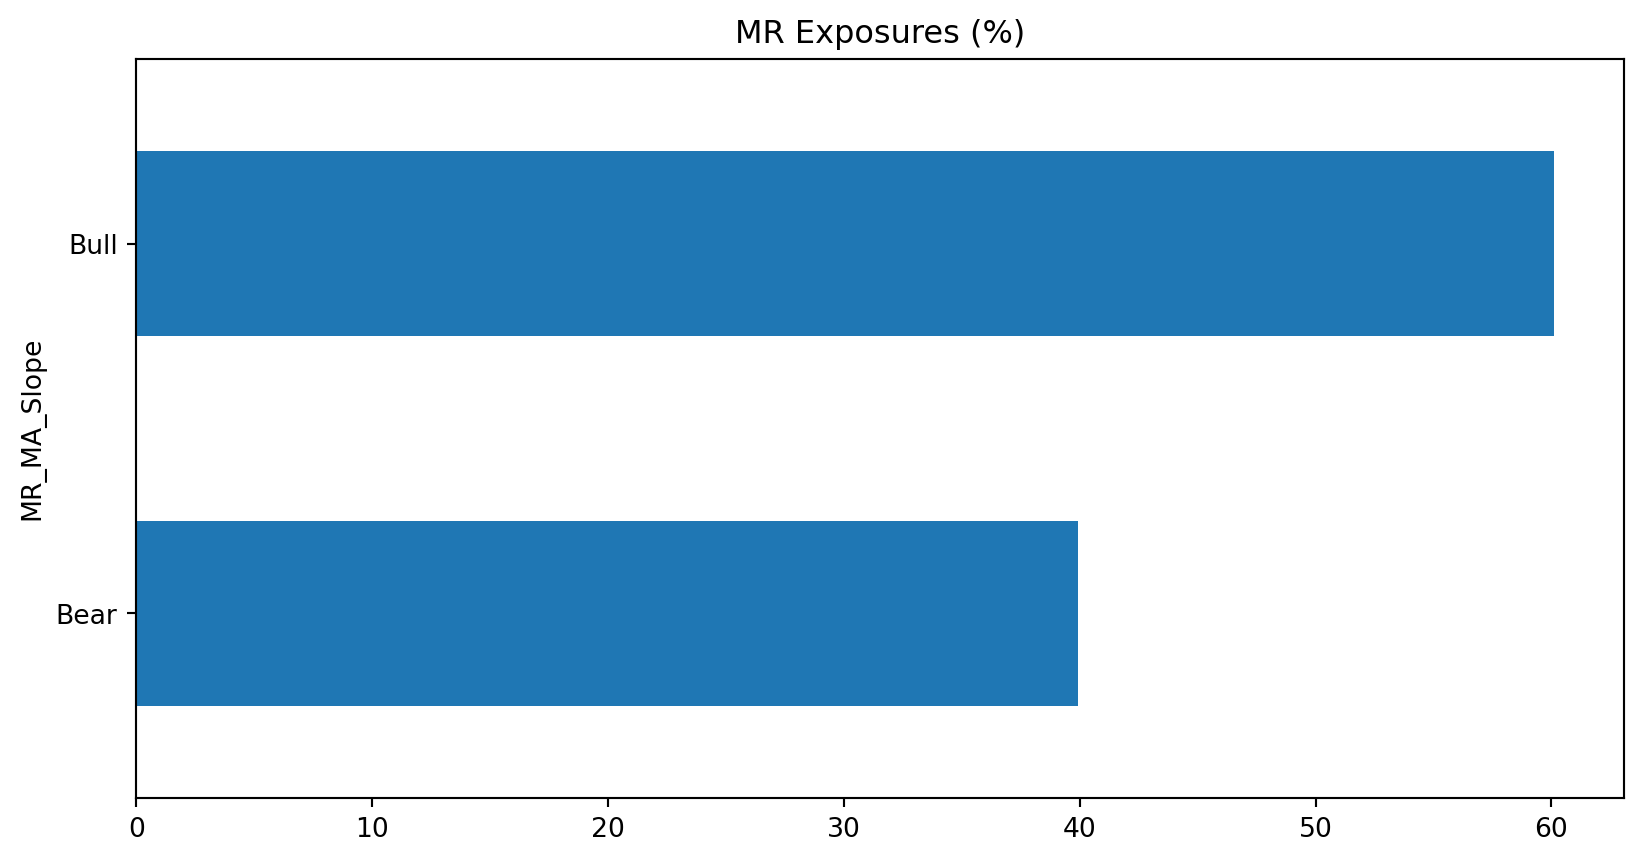

In [5]:
mr_share.plot.barh(title='MR Exposures (%)', figsize=(10,5));

Bitcoin has spent 60% of the time in a Bull Market regime and 40% on a Bear market regime.

#### What's the average time a bull/bear state has?

            Average MR Duration (Days)
Bull State                      129.10
Bear State                       85.70


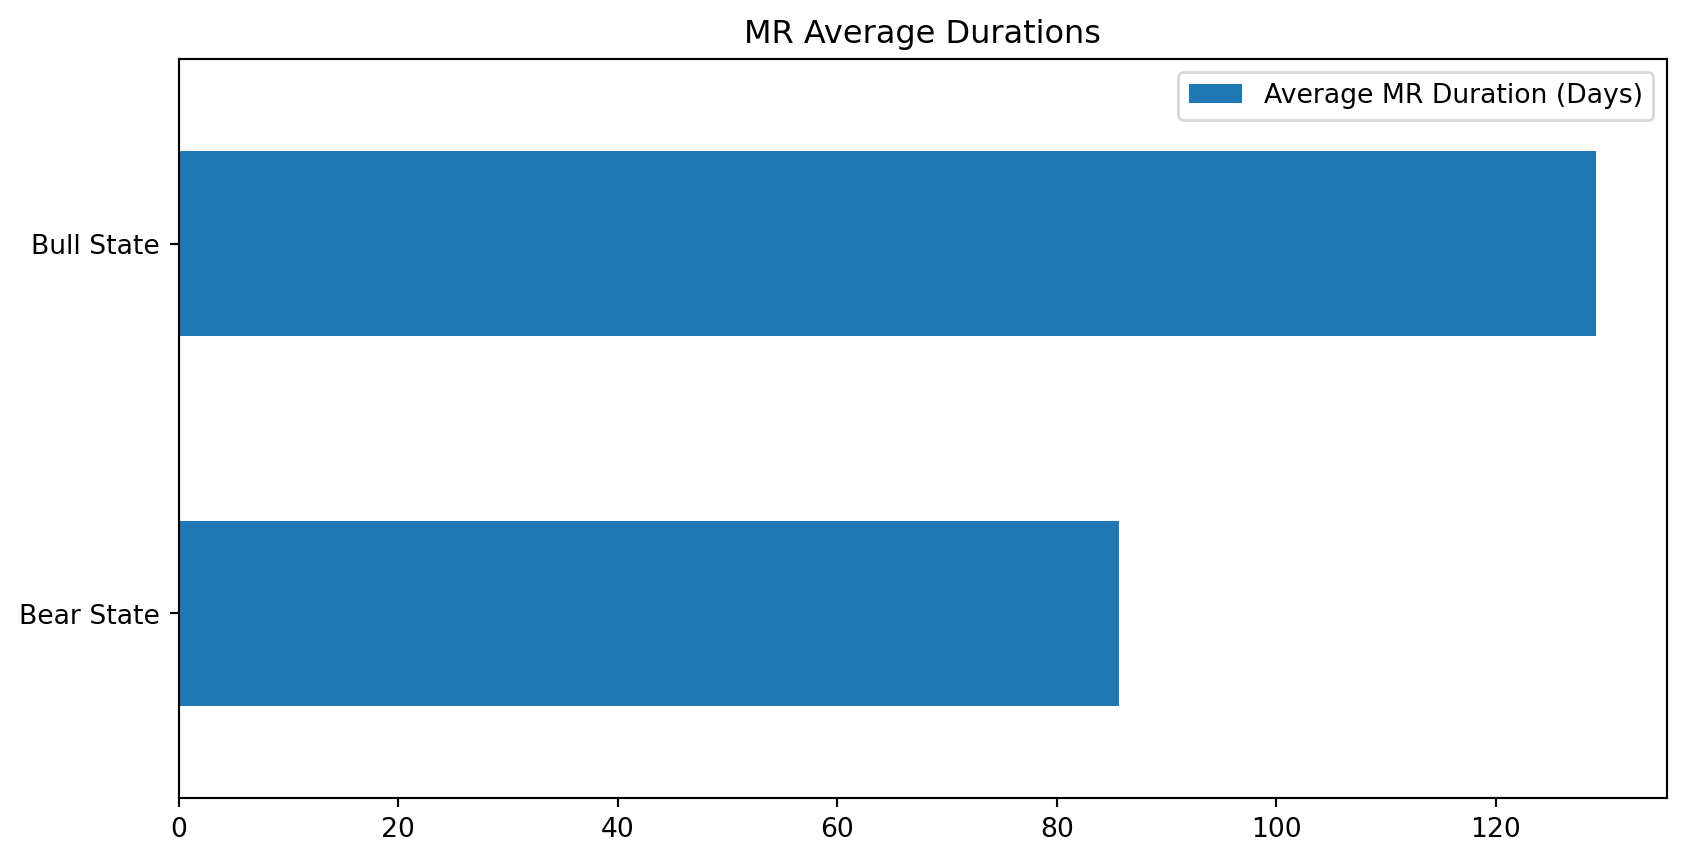

In [6]:
MR_Series = quotes['MR_MA_Slope']

groups = MR_Series.groupby((MR_Series != MR_Series.shift()).cumsum())
durations = groups.size().reset_index(drop=True)
regimes = groups.first().reset_index(drop=True)

bull_state_durations = (durations[regimes == "Bull"]).reset_index(drop=True)
bear_state_durations = (durations[regimes == "Bear"]).reset_index(drop=True)

MR_Exposures_Average_Duration = pd.DataFrame(
    columns=["Average MR Duration (Days)"], 
    index=["Bull State","Bear State"],
    data = [round(bull_state_durations.mean(),1), round(bear_state_durations.mean(),1)]
    )

print(MR_Exposures_Average_Duration)
MR_Exposures_Average_Duration.sort_values(by="Average MR Duration (Days)").plot.barh(figsize=(10, 5), title='MR Average Durations');

    On average a Bull MR has lasted ~129 days, a Bear MR has lasted on average ~86 days.

 Min: 7
 Max: 484


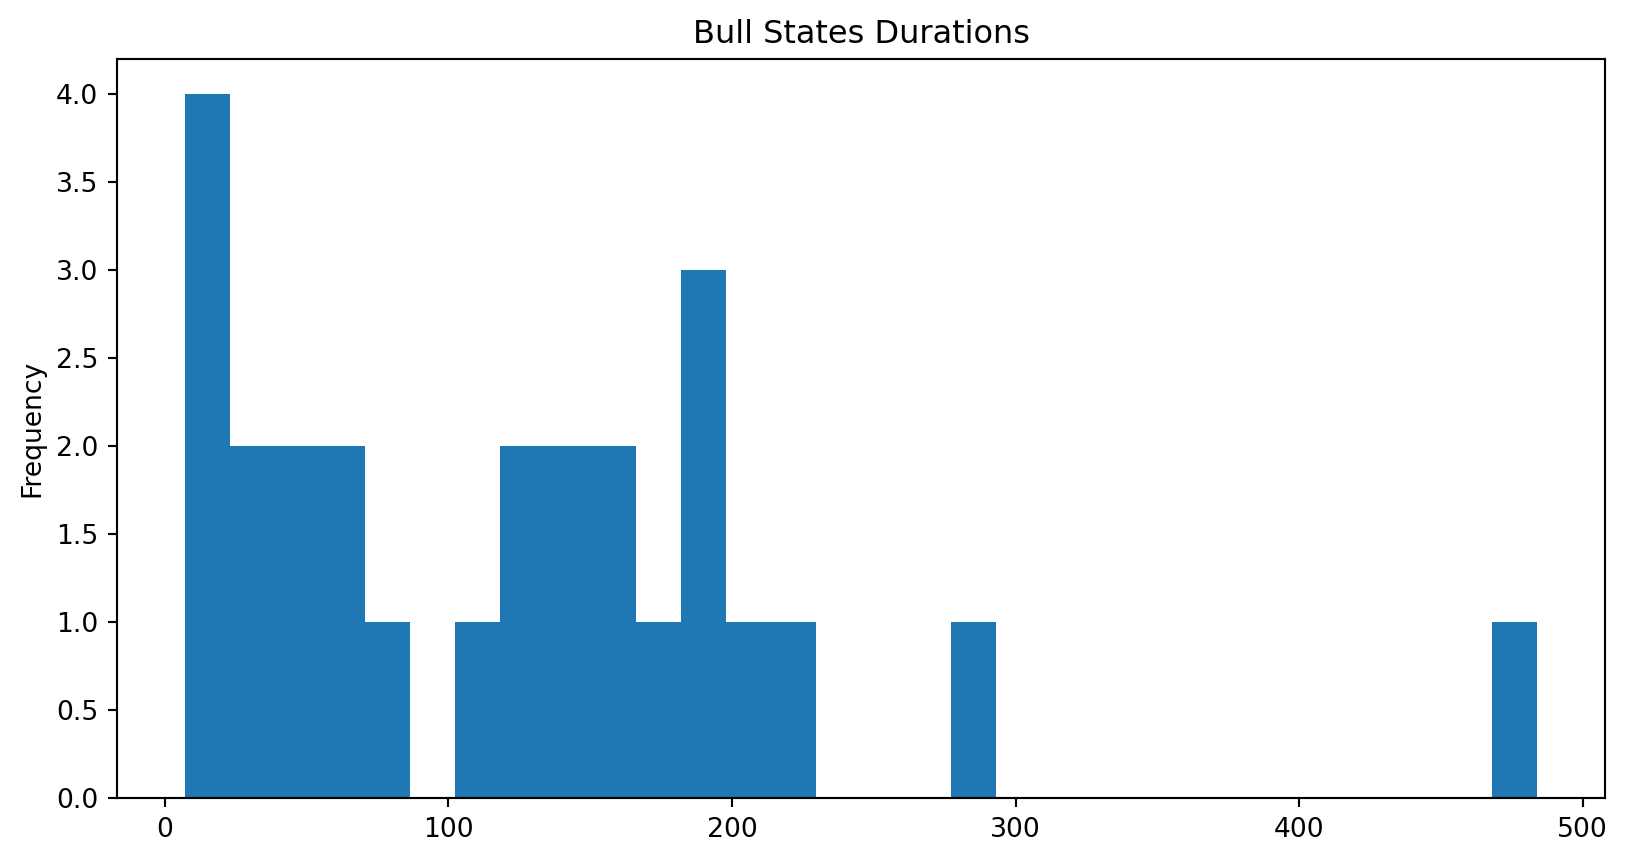

In [7]:
print(f" Min: {bull_state_durations.min():.0f}")
print(f" Max: {bull_state_durations.max():.0f}")
bull_state_durations.plot.hist(bins=30, figsize=(10, 5), title='Bull States Durations');

Biggest Bull Market registered lasted 484 days, that's a 1.32 years, giving investors enought time to get in.

 Min: 9
 Max: 222


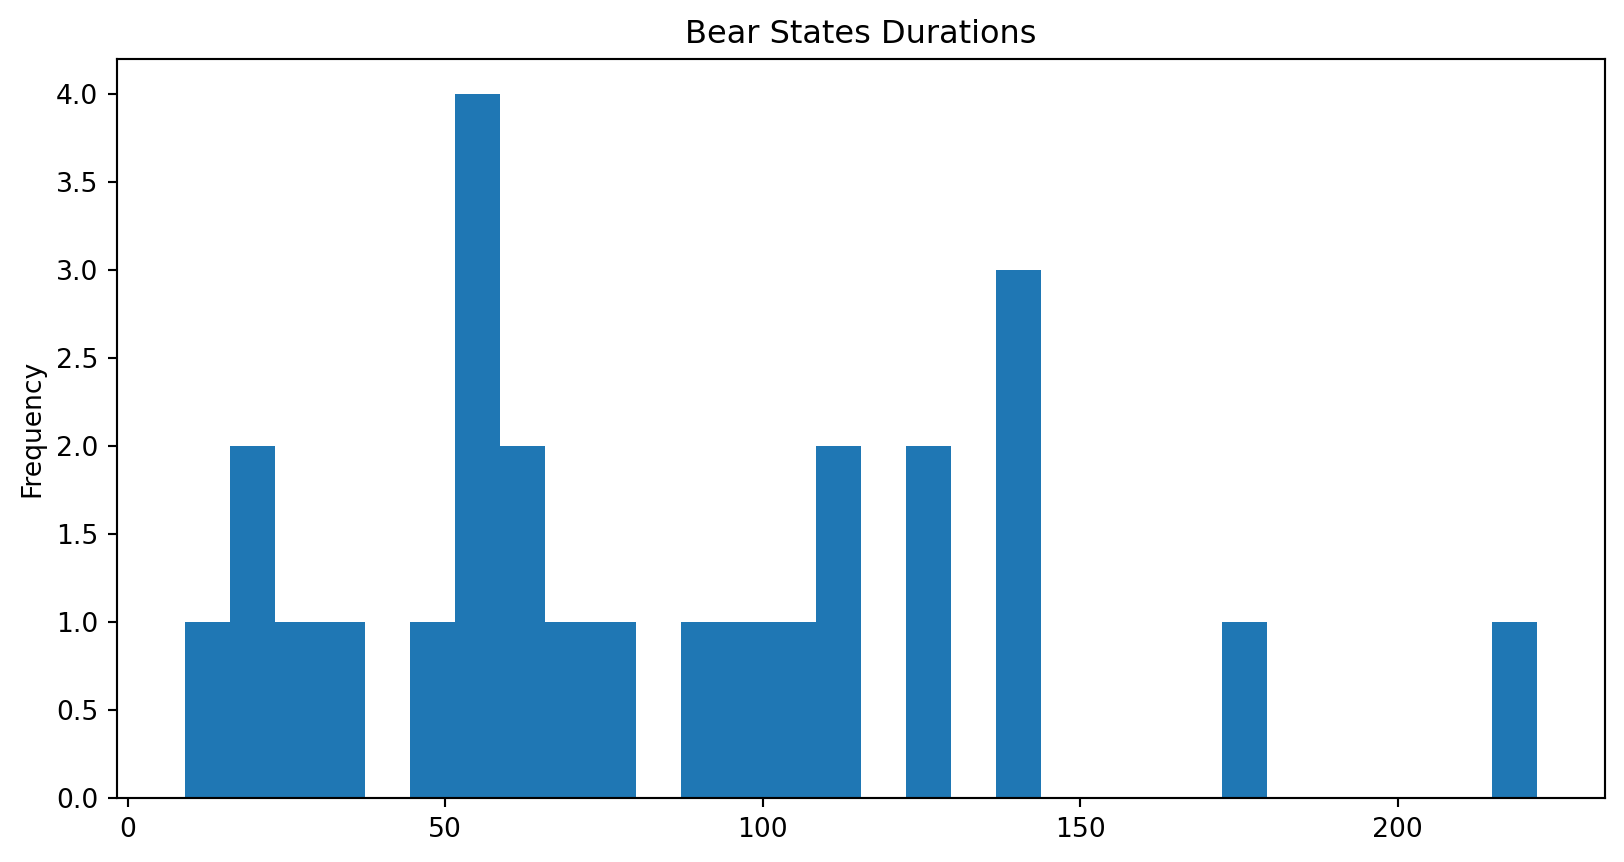

In [8]:
print(f" Min: {bear_state_durations.min():.0f}")
print(f" Max: {bear_state_durations.max():.0f}")
bear_state_durations.plot.hist(bins=30, figsize=(10, 5), title='Bear States Durations');

When Bitcoin enters in a Bear Market regime you can expect it to last at least 9 days, since this is the minimum registered for the studied period. Longest Bear MR has lasted 222 days, less than half of the biggest Bull MR (484 days).

## Can a savy investor take advantage of this data to increase its portfolio Sharpe Ratio?

### MR Vectorized Backtest

In [9]:
#| include: false

quotes.tail(2)

,Open,High,Low,Close,MR_MA_Slope
Date,,,,,
2026-02-17,68843.09,69201.87,66615.28,67494.22,Bear
2026-02-18,67473.45,68332.81,66767.72,66877.57,Bear


In [10]:
#| code-fold: show

def Market_Regime_backtest(quotes_df: pd.DataFrame):

    df = pd.DataFrame()
    bh_returns = quotes_df['Close'].pct_change(1)
    df.loc[:, 'BH'] = bh_returns.add(1).cumprod()
    
    for col in quotes_df.iloc[:, 4:].columns:
        for regime in quotes_df[f'{col}'].unique().tolist():
            
            signals = np.where(quotes_df[f'{col}'].shift(1) == regime, 1, 0)
            strategy_returns = bh_returns * signals
            df.loc[:, f'{col}_{regime}'] = strategy_returns.add(1).cumprod()

    df.iloc[0] = 1

    return df 

timer.start()
market_regimes_bt_comparison = Market_Regime_backtest(quotes)
timer.stop()
market_regimes_bt_comparison


[*] Total runtime: 3.01 ms


,BH,MR_MA_Slope_Bull,MR_MA_Slope_Bear
Date,,,
2010-10-24,1.00,1.00,1.00
2010-10-25,1.15,1.15,1.00
2010-10-26,1.31,1.31,1.00
2010-10-27,1.63,1.63,1.00
2010-10-28,1.51,1.51,1.00
...,...,...,...
2026-02-14,606675.00,155169.32,3.91
2026-02-15,598158.15,155169.32,3.85
2026-02-16,598636.14,155169.32,3.86


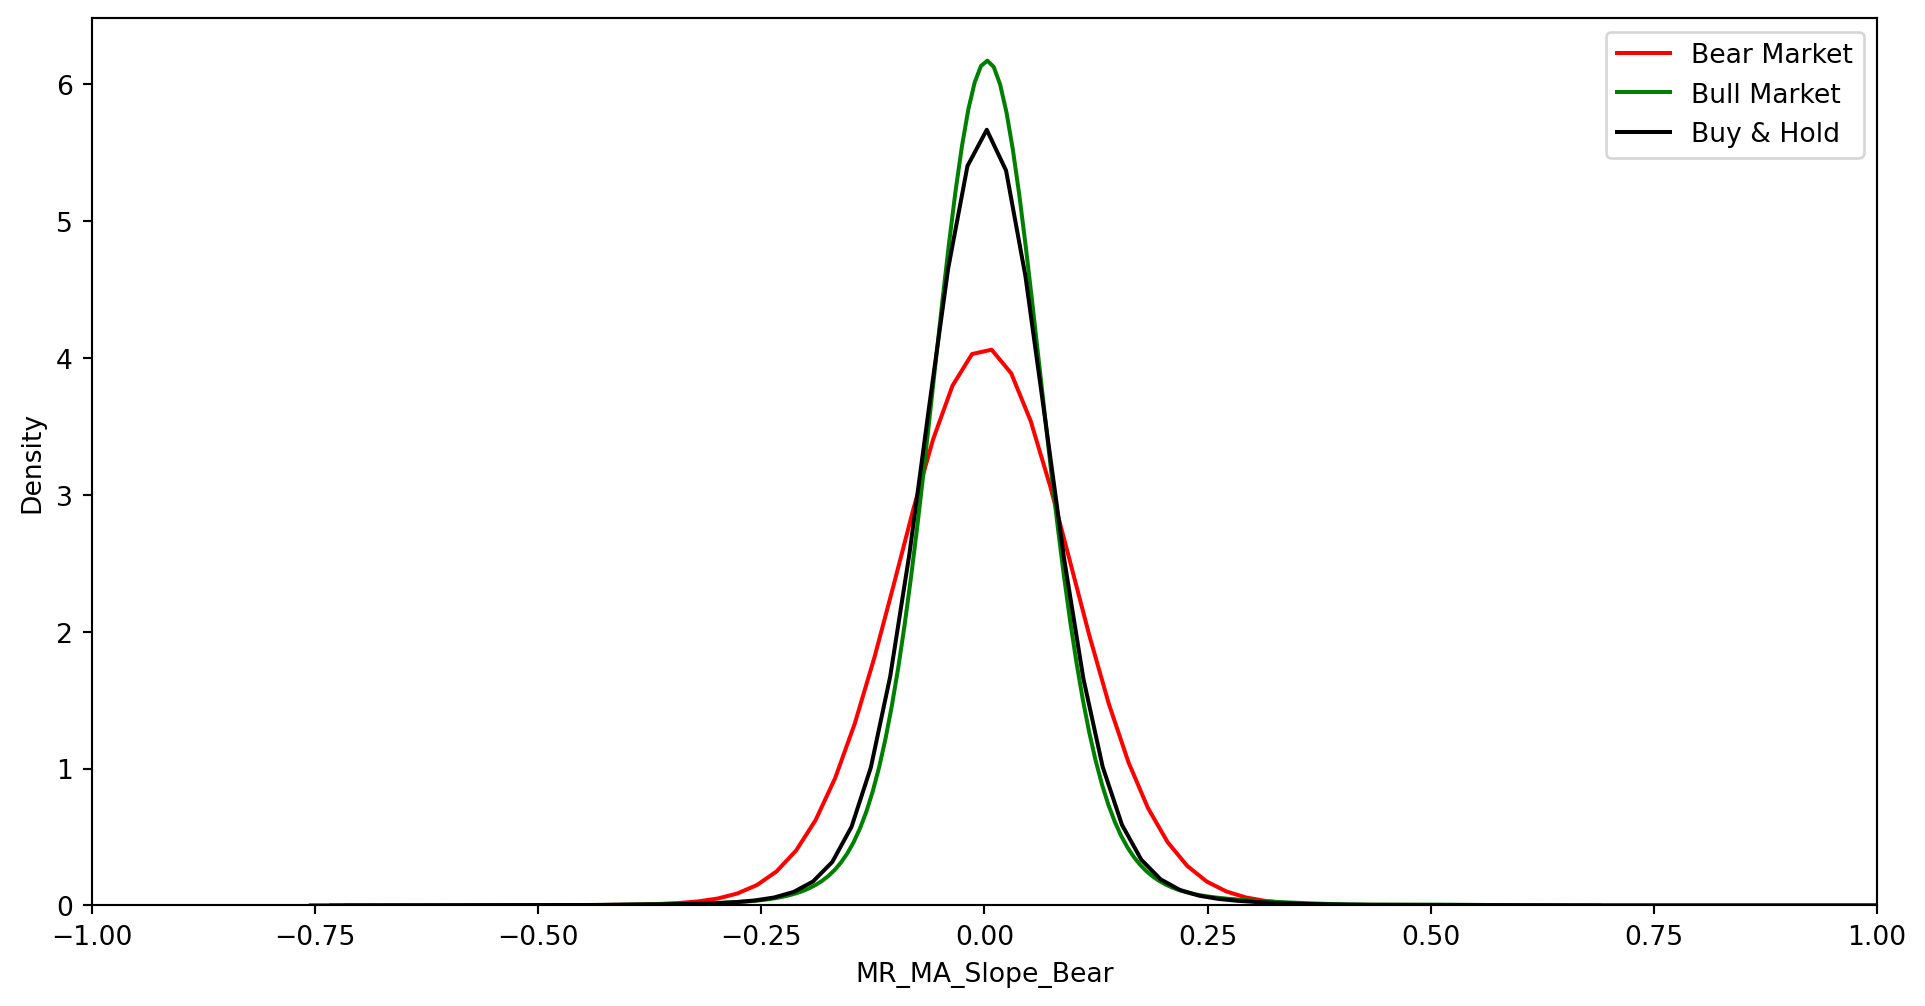

In [11]:
plt.figure(figsize=(12, 6))

bear = market_regimes_bt_comparison['MR_MA_Slope_Bear'].pct_change()
bull = market_regimes_bt_comparison['MR_MA_Slope_Bull'].pct_change()

sns.kdeplot(bear[bear != 0].dropna(), color="red", label="Bear Market", bw_adjust=5)
sns.kdeplot(bull[bull != 0].dropna(), color="green", label="Bull Market", bw_adjust=5)
# sns.kdeplot(market_regimes_bt_comparison['get_Market_Regime_single_MA_Bear'].pct_change().fillna(0), color="red", label="Bear Market")
# sns.kdeplot(market_regimes_bt_comparison['get_Market_Regime_single_MA_Bull'].pct_change().fillna(0), color="green", label="Bull Market")
sns.kdeplot(market_regimes_bt_comparison['BH'].pct_change().fillna(0), color="black", label="Buy & Hold", bw_adjust=5)

# plt.axvline(tv_maxdd25.mean(), ls="--", color="yellow")
plt.xlim(-1, 1)
plt.legend();

A quick annalysis of this distribution plot shows that Holding Bitcoin only on a Bull Market has reduced left tail risk vs both Buy & Hold and Bear Marke regime.
Without much surprise Bear Market potfolio has bigger lef tail risk.
Buy & Hold portfolio sits on the middle of both Market Regimes states.

In [12]:
from MyCustomLibrary.main import plot_comparative_graph

plot_comparative_graph(market_regimes_bt_comparison, title="Market Regime Annalysis")

Visually we may have a perception that Bull portfolio behaves similarly to Buy & Hold, even underperforming in terms of return.
Bear Portfolio leaves us no doubts on wether it may be better to just avoid being exposed to Bitcoin on a Bear Market Regime.

In [13]:
from MyCustomLibrary.backtester_tools import strategy_performance_metrics

strategy_performance_metrics(market_regimes_bt_comparison, rf=0.0)

,BH,MR_MA_Slope_Bull,MR_MA_Slope_Bear
CAGR %,137.68,118.05,9.00
Ann. Vola %,130.51,79.64,103.50
Max Drawdown %,-93.07,-94.08,-82.40
VaR 5%,-6.12,-4.62,-2.99
Time in Market %,99.62,59.80,39.83
Sharpe,1.05,1.48,0.09
Sortino,1.91,1.50,0.15
Calmar,1.48,1.25,0.11
Efficiency,1.38,1.97,0.23


Surprisingly B&H has returned an excess ~20% annualized returns than Bull Market Portfolio, at the expense of Higher Annualized Volatility (+50%) and slightly lower drawdown (-1%). 
    
Resulting in a lower Annualized Volatility, Bull portfolio managed to increase B&H Sharpe Ratio from 1.05 to 1.48, even though a retail amateur investor may prefer higher returns given by the B&H portfolio, a sophisticated investor will seek higher Sharpe Ratio portfolios like the Bull one.

Bull portfolio had active exposure to Bitcoin circa 60% of the time vs 100% B&H, leading to a higher Efficiency(CAGR/Exposure) of Capital Use, providing an opportunity to invest in other ideas/strategies while Bitcoin was on a Bear Market, improving even further it's relevance to a Sophisticated Investor.

In [14]:
from MyCustomLibrary.backtester_tools import metrics_time_window_analysis

metrics_time_window_analysis(market_regimes_bt_comparison, lookbacks=[6, 12, 24, 48, 60])

,BH,MR_MA_Slope_Bull,MR_MA_Slope_Bear
6-month,66.5%,61.5%,58.7%
12-month,75.1%,69.4%,63.0%
24-month,83.9%,83.2%,59.0%
48-month,100.0%,98.5%,62.0%
60-month,100.0%,100.0%,63.2%


In every lookback studied [6, 12, 24, 48, 60], B&H portfolio has been the most reliable portfolio in terms of Wealth preservation, guaranteeing in a 48 month or 4 years period, 0% losses, meaning that an investor that's able to invest today in Bitcoin, can expect with ~84% probability to be in a profit in a 2 years period and 100% in a 4 years period.

## Final Findings:

Bitcoin has spent 60% of the time in a Bull Market regime and 40% on a Bear market regime. Longest Bull market has lasted more than 2x longest Bear Market. On average a Bull market lasts 129 days vs 86 days for Bear Markets.

Even though it may sound counterintuitive, **B&H portfolio has returned ~20% excess return vs Bull portfolio** with slightly -1% lower drawdown. This set & forget approach might the **best one to retail investors** since it has also been the one **most reliable on wealth preservation**, guaranteeing a profit 100% of the time in a 4 years period.

**Bull portfolio** has returned 118% annualized return with **-50% volatility** vs B&H and on only **60% of the time**. Thanks to Volatility reduction, **Sharpe ratio improved** by 0.43 to 1.48. Although Bull portfolio has returned less than B&H, it also **has its place amongst sophisticated investors** who seek higher Sharpe Ratio portfolios and look out for more efficient ways to extract capital of the market with less exposure time, reducing Cost of opportunity of having capital tied up on an investment.

**Bear portfolio**, which is, exposure to Bitcoin during Bear Market Regime, it is terrible in any metric annalyzed and **should be avoided**, as it doesn't bring any real tangible advantage over Bull Portfolio.